## Librerias

In [2]:
import pandas as pd

## Carga de datos

In [4]:
df = pd.read_csv('../../data/clean_data_09-03-2026.csv',parse_dates=['insert_date'])
df

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,78,75.0,Malaga,2018-07-31,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,33,52.0,Madrid,2020-01-10,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,148,142.0,Sevilla,2019-07-29,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,292,306.0,Barcelona,2020-01-10,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,36,39.0,Girona,2019-02-19,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6610,27237828,Entire home/apt,1500.0,True,22,47,77,78,100.0,1,10.0,Girona,2018-08-30,True
6611,27241318,Entire home/apt,3130.0,True,26,37,37,243,100.0,1,7.0,Mallorca,2020-04-23,True
6612,27244243,Entire home/apt,990.0,True,24,40,40,40,NaN,0,NaN,Girona,2018-08-30,NaN
6613,27244794,Entire home/apt,720.0,True,0,0,0,0,100.0,1,6.0,Girona,2019-12-31,True


## Marketing

- Precio medio general - por room type
- Precio medio general
- Avg number_of_reviews (total reviews = reservas aprox)

In [7]:
# Precio medio general - por room type
df.groupby('room_type')[['price']].mean().round(2)

,price
room_type,
Entire home/apt,1241.61
Hotel room,1063.03
Private room,448.24
Shared room,324.15


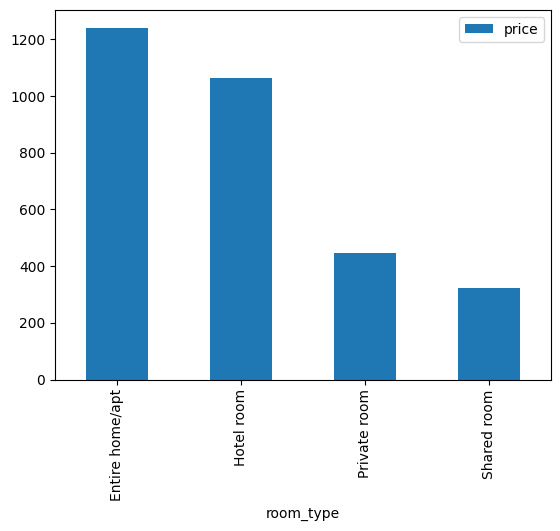

In [8]:
# Grafico importe medio por romm type
df.groupby('room_type')[['price']].mean().sort_values(by='price',ascending=False).plot.bar();

## Cliente

Average rating general
Average reviews per month

In [1]:
import pandas as pd

df = pd.read_csv("/Users/lgm/Documents/ProjecteData/Equip_25/Data/clean_data_09-03-2026.csv")

# KPI 1 — Average rating
avg_rating = df["review_scores_rating"].dropna().mean()

# KPI 2 — Average reviews per month
avg_reviews_month = df["reviews_per_month"].dropna().mean()

print("KPI RESULTS")
print("---------------------")
print(f"Avg rating (all scores): {avg_rating:.2f}")
print(f"Avg reviews per month: {avg_reviews_month:.2f}")

KPI RESULTS
---------------------
Avg rating (all scores): 91.99
Avg reviews per month: 123.69


## Operaciones
- Oferta total disponible
- Porcentaje de oferta disponible
- Disponibles en el próximo mes
- Completos/reservados
- Ratio de ocupación mensual
- Ratio de ocupación anual

In [171]:
# Creación del df para operaciones
df_operaciones = df.copy()

availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

# apartamentos totalmente ocupados
df_operaciones["fully_booked"] = (df_operaciones[availability_cols] == 0).all(axis=1)

# ratios de ocupación
df_operaciones["occ_month"] = (30 - df_operaciones["availability_30"]) / 30
df_operaciones["occ_2month"] = (60 - df_operaciones["availability_60"]) / 60
df_operaciones["occ_3month"] = (90 - df_operaciones["availability_90"]) / 90
df_operaciones["occ_year"] = (365 - df_operaciones["availability_365"]) / 365

occupancy_cols = [
    "occ_month",
    "occ_2month",
    "occ_3month",
    "occ_year"
]
df_operaciones['has_availability'].value_counts()

has_availability
True     6087
False     528
Name: count, dtype: int64

In [187]:
# Oferta total disponible
total_anuncios = df_operaciones["apartment_id"].nunique()                      
apartamentos_disponibles = df_operaciones["has_availability"].sum()                       
available_30 = (df_operaciones["availability_30"] > 0).sum()                            
ratio_oferta_disponible = round((available_30 / apartamentos_disponibles) * 100, 2)     
fully_booked_active = df_operaciones[
    (df_operaciones["fully_booked"]) & 
    (df_operaciones["has_availability"])
].shape[0]                                                                      


In [173]:
pd.crosstab(
    df_operaciones["fully_booked"],
    df_operaciones["has_availability"]
)

has_availability,False,True
fully_booked,,
False,473,5274
True,55,813


In [174]:
# Oferta disponible por tipo de habitación
oferta_tipo = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("room_type")["apartment_id"]
    .nunique()
    .reset_index(name="alojamientos_disponibles")
    .sort_values(by="alojamientos_disponibles", ascending=False)   
)
oferta_tipo

,room_type,alojamientos_disponibles
0,Entire home/apt,3440
2,Private room,1169
3,Shared room,29
1,Hotel room,23


In [175]:
# Oferta disponible por ciudad
oferta_ciudad = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("city")["apartment_id"]
    .nunique()
    .reset_index(name="alojamientos_disponibles")
    .sort_values(by="alojamientos_disponibles", ascending=False)
)
oferta_ciudad

,city,alojamientos_disponibles
0,Barcelona,1411
2,Madrid,908
4,Mallorca,760
1,Girona,733
6,Sevilla,286
3,Malaga,257
7,Valencia,218
5,Menorca,88


In [176]:
# Disponobilidad media general
disponibilidad_media = df_operaciones[availability_cols].mean().round(0)
disponibilidad_media

availability_30      12.0
availability_60      27.0
availability_90      44.0
availability_365    186.0
dtype: float64

In [177]:
# Ratio de ocupación estimada (30,60,90,365)
ratio_ocupacion = (df_operaciones[occupancy_cols].mean() * 100).round(2)
ratio_ocupacion

occ_month     59.53
occ_2month    54.66
occ_3month    51.06
occ_year      48.94
dtype: float64

In [178]:
ocupacion_ciudad = (
    df_operaciones
    .groupby("city")[occupancy_cols]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)
ocupacion_ciudad

,city,occ_month,occ_2month,occ_3month,occ_year
0,Barcelona,63.17,57.46,52.96,50.31
1,Girona,51.99,48.33,46.60,46.83
2,Madrid,65.42,59.84,55.63,55.18
3,Malaga,59.35,52.28,47.29,44.36
4,Mallorca,56.47,53.06,50.61,42.89
5,Menorca,51.22,49.59,47.65,45.86
6,Sevilla,54.15,49.47,45.02,45.46
7,Valencia,55.17,50.87,47.26,49.79


In [179]:
kpi_operaciones = {
    "anuncios_totales": int(total_anuncios),
    "apartamentos_disponibles": int(apartamentos_disponibles),
    "available_supply_%": float(ratio_oferta_disponible),
    "available_next_30_days": int(available_30),
    "fully_booked": int(fully_booked_active),
    "occupancy_30_days_%": float(ratio_ocupacion["occ_month"]),
    "occupancy_year_%": float(ratio_ocupacion["occ_year"])
}
kpi_operaciones_df = pd.DataFrame(
    list(kpi_operaciones.items()),
    columns=["KPI", "Valor"]
)

kpi_operaciones_df

,KPI,Valor
0,anuncios_totales,6615.00
1,apartamentos_disponibles,6087.00
2,available_supply_%,76.57
3,available_next_30_days,4661.00
4,fully_booked,813.00
5,occupancy_30_days_%,59.53
6,occupancy_year_%,48.94


In [181]:
df_operaciones.to_csv('../../data/data_cleaning/operaciones_11-03-2026.csv', index=False)